In [2]:
%load_ext autoreload
%autoreload 2
import pprint
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import utils
import pylupnt as pnt

pp = pprint.PrettyPrinter()

## Single satellite, single orbit, no resources

In [144]:
# Seed
np.random.seed(0)

# Tasks
targets = ["A", "B", "C", "D"]
N_targets = len(targets)
vtws = np.array(
    [
        [0, 2.5],
        [2.25, 3.5],
        [2.5, 5.5],
        [3.5, 6.5],
    ]
)
durations = np.array([2, 1, 1.5, 1.5])
rewards = np.arange(1, N_targets + 1)
power_gen = np.array([-0.1, -0.2, -0.3, -0.4])
data_rate = np.array([0.5, 0.6, 0.7, 0.8])
max_tasks = np.ones(N_targets, dtype=int) * 1
T = 10

# Tasks
dt = 0.5
task_otws = []
task_idxs = []
for i in range(N_targets):
    s = vtws[i][0]
    e = vtws[i][1]
    while s + durations[i] <= e:
        task_otws.append([s, s + durations[i]])
        task_idxs.append(i)
        s += dt
task_otws = np.array(task_otws)
task_idxs = np.array(task_idxs)
N_tasks = len(task_idxs)

# Transition time (random symmetric matrix with zeros on the diagonal)
rnd_matrix = np.random.rand(N_targets, N_targets)
rnd_matrix[np.diag_indices(N_targets)] = 0
trans_time = (rnd_matrix + rnd_matrix.T) / 2 * 0

print("Targets\n", targets)
print("Rewards\n", rewards)
print("VTWs\n", vtws)
print("Durations\n", durations)
print("Margin\n", vtws[:, 1] - vtws[:, 0] - durations)
print("Task idxs\n", task_idxs)
print("Task otws\n", task_otws)
print("Transition times\n", trans_time)

Targets
 ['A', 'B', 'C', 'D']
Rewards
 [1 2 3 4]
VTWs
 [[0.   2.5 ]
 [2.25 3.5 ]
 [2.5  5.5 ]
 [3.5  6.5 ]]
Durations
 [2.  1.  1.5 1.5]
Margin
 [0.5  0.25 1.5  1.5 ]
Task idxs
 [0 0 1 2 2 2 2 3 3 3 3]
Task otws
 [[0.   2.  ]
 [0.5  2.5 ]
 [2.25 3.25]
 [2.5  4.  ]
 [3.   4.5 ]
 [3.5  5.  ]
 [4.   5.5 ]
 [3.5  5.  ]
 [4.   5.5 ]
 [4.5  6.  ]
 [5.   6.5 ]]
Transition times
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


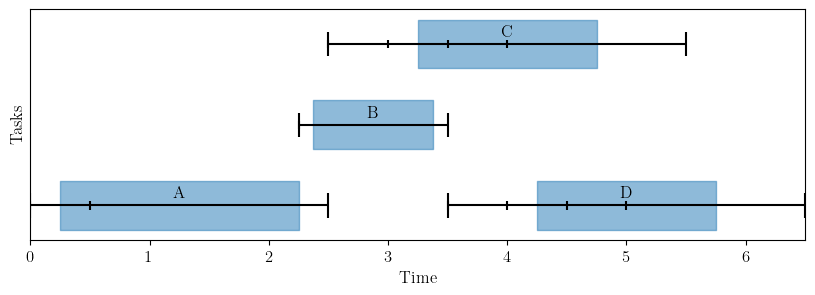

In [145]:
plt.rcParams.update({"font.size": 12})
plt.figure(figsize=(10, 3))
utils.plot_windows(targets, vtws, durations, task_otws, task_idxs)

## Time-Continuous

In [67]:
# Variables

# - (s, p1, p2, ..., pN, e)
x = cp.Variable(N_targets, boolean=True)
y = cp.Variable((N_targets, N_targets), boolean=True)
t = cp.Variable(N_targets)
# Objective
# - Maximize the sum of rewards (TODO: add function of t)
rho = rewards
objective = cp.Maximize(rho @ x)
# Constraints
constraints = []
# - Start and end time
s = vtws[:, 0]
e = vtws[:, 1]
d = durations
constraints.append(t - s >= 0)
constraints.append(e - d - t >= 0)
for i in range(N_targets):
    idxs = np.ones(N_targets, dtype=bool)
    idxs[i] = False
    constraints.append(
        t[idxs] - t[i] - d[i] - trans_time[i, idxs]
        >= -T * (3 - x[i] - x[idxs] - y[i, idxs])
    )
    constraints.append(
        t[i] - t[idxs] - d[idxs] - trans_time[idxs, i]
        >= -T * (2 - x[i] - x[idxs] + y[i, idxs])
    )
problem = cp.Problem(objective, constraints)
problem.solve()
print("Problem status:", problem.status)
print("Optimal value:", problem.value)

Problem status: optimal
Optimal value: 10.0


In [68]:
# selected_tasks = np.where(x.value[:, 1:-1])[1]
selected_targets = np.round(x.value).astype(bool)
task_otws_ = np.array([t.value, t.value + durations]).T
task_idxs_ = np.arange(N_targets)
selected_tasks_ = selected_targets
print("Selected targets:", np.where(selected_targets)[0])
print("Start times:", t.value)

Selected targets: [0 1 2 3]
Start times: [0.25 2.25 3.5  5.  ]


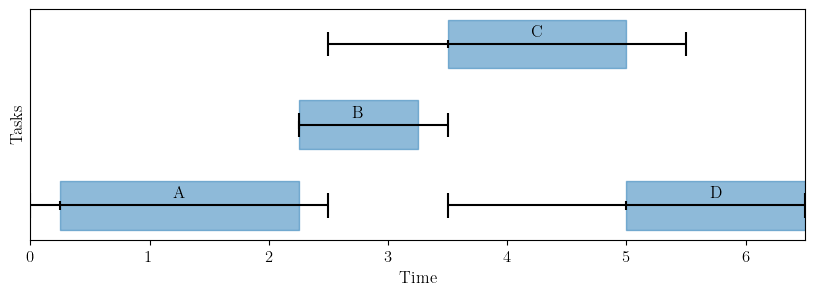

In [69]:
plt.rcParams.update({"font.size": 12})
plt.figure(figsize=(10, 3))
utils.plot_windows(
    targets, vtws, durations, task_otws_, task_idxs_, selected_tasks=selected_tasks_
)

In [70]:
x = np.array([1, 0, 1, 0]).astype(int)
t = vtws[:, 0]
y = np.zeros((4, 4))
y[2, 1] = 1
y[np.triu_indices(N_targets, 1)] = 1

print(t - s >= 0)
print(e - d - t >= 0)
# print(y[np.diag_indices(N_targets)] == 0)
# print(y[np.triu_indices(N_targets, 1)] == 1 - y[np.tril_indices(N_targets, -1)])
for i in range(N_targets):
    idxs = np.ones(N_targets, dtype=bool)
    idxs[i] = False
    print(i)
    print(
        t[idxs] - t[i] - d[i] - 0 * trans_time[i, idxs]
        >= -T * (3 - x[idxs] - x[i] - y[i, idxs])
    )
    print(
        t[i] - t[idxs] - d[idxs] - trans_time[idxs, i]
        >= -T * (2 - x[i] - x[idxs] + y[i, idxs])
    )

[ True  True  True  True]
[ True  True  True  True]
0
[ True  True  True]
[ True  True  True]
1
[ True  True  True]
[ True  True  True]
2
[ True  True  True]
[ True  True  True]
3
[ True  True  True]
[ True  True  True]


In [71]:
i = 2
idxs = np.ones(N_targets, dtype=bool)
idxs[i] = False
print("t[i] =", t[i])
print("x[i] =", x[i])
print("x[idxs] =", x[idxs])
print("t[idxs] =", t[idxs])
print("d[idxs] =", d[idxs])
print("y[idxs] =", y[i, idxs])
print("trans_time[i, idxs] =", trans_time[i, idxs])
print("lhs", t[idxs] - t[i] - d[idxs] - 0 * trans_time[i, idxs])
print("rhs1", -T * (3 - x[idxs] - x[i] - y[i, idxs]))
print("rhs2", -T * (2 - x[idxs] - x[i] + y[i, idxs]))
print(
    t[idxs] - t[i] - d[i] - 0 * trans_time[i, idxs]
    >= -T * (3 - x[idxs] - x[i] - y[i, idxs])
)
print(
    t[i] - t[idxs] - d[idxs] - trans_time[idxs, i]
    >= -T * (2 - x[i] - x[idxs] + y[i, idxs])
)

t[i] = 2.5
x[i] = 1
x[idxs] = [1 0 0]
t[idxs] = [0.   2.25 3.5 ]
d[idxs] = [2.  1.  1.5]
y[idxs] = [0. 1. 1.]
trans_time[i, idxs] = [0. 0. 0.]
lhs [-4.5  -1.25 -0.5 ]
rhs1 [-10. -10. -10.]
rhs2 [ -0. -20. -20.]
[ True  True  True]
[ True  True  True]


## Task-Discrete

In [72]:
# Variables
# - (s, p1, p2, ..., pN, e)
x = cp.Variable((N_tasks + 2, N_tasks + 2), boolean=True)

# Objective
# - Maximize the sum of rewards
rho = np.concatenate([[0], rewards[task_idxs], [0]])
objective = cp.Maximize(rho @ cp.sum(x, axis=1))

# Constraints
constraints = []

# - Each task is executed at most N_i times
for i in range(N_targets):
    tmp = np.where(task_idxs == i)[0]
    constraints.append(cp.sum(x[1 + tmp, :]) <= max_tasks[i])

# - Diagonal and dummy start and end tasks
constraints.append(cp.sum(x[0, :]) == 1)
constraints.append(cp.sum(x[:, 0]) == 0)
constraints.append(cp.sum(x[-1, :]) == 0)
constraints.append(cp.sum(x[:, -1]) == 1)
constraints.append(x[np.diag_indices(N_tasks + 2)] == 0)

# - Precedence constraints (what tasks can be executed after each task)
for i in range(N_tasks):
    idx = task_idxs[i]
    feasible_x = np.zeros(N_tasks + 2, dtype=bool)
    feasible_x[-1] = True  # End task
    feasible_x[1:-1] = (
        task_otws[i][1] + trans_time[idx, task_idxs] <= task_otws[:, 0]
    )  # Next tasks
    constraints.append(x[1 + i, :] <= feasible_x)
    constraints.append(cp.sum(x[1 + i, :]) == cp.sum(x[:, 1 + i]))

problem = cp.Problem(objective, constraints)
problem.solve()
print("Problem status:", problem.status)
print("Optimal value:", problem.value)

Problem status: optimal
Optimal value: 10.0


In [73]:
# selected_tasks = np.where(x.value[:, 1:-1])[1]
selected_tasks = x.value[:, 1:-1].any(axis=0)
selected_targets = task_idxs[selected_tasks]
print("Selected tasks:", np.where(selected_tasks)[0])
print("Selected targets:", selected_targets)

Selected tasks: [ 0  2  5 10]
Selected targets: [0 1 2 3]


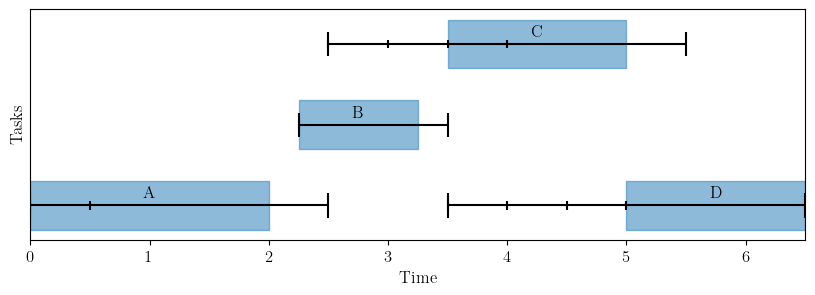

In [74]:
plt.rcParams.update({"font.size": 12})
plt.figure(figsize=(10, 3))
utils.plot_windows(
    targets, vtws, durations, task_otws, task_idxs, selected_tasks=selected_tasks
)

## Time-Discrete (uniform)

In [75]:
t = None
data_min = 0
data_max = 1e3
data_initial = data_min + 0

power_min = 0
power_max = 1e3
power_initial = power_max - 1

lambda_data = 0.5 / data_max
lambda_power = 0.1 / power_max
N_steps = int((vtws[:, 1].max() - vtws[:, 0].min()) / dt)

# Variables
x = cp.Variable(N_targets, boolean=True)
t_start = cp.Variable((N_targets, N_steps), boolean=True)  # Start time
t_tasks = cp.Variable((N_targets, N_steps), boolean=True)  # Task times

# Resources
data_var = cp.sum(cp.multiply(t_tasks, data.reshape(-1, 1)), axis=0)
power_var = cp.sum(cp.multiply(t_tasks, power.reshape(-1, 1)), axis=0)
lower_diag = np.tril(np.ones((N_steps, N_steps)), k=0)

# Objective
objective = cp.Maximize(
    rewards
    @ x
    # - lambda_data * cp.max(lower_diag @ data_var)
    # - lambda_data * cp.mean(lower_diag @ data_var)
    # + lambda_power * cp.min(lower_diag @ power_var)
    # + lambda_power * cp.mean(lower_diag @ power_var)
)

# Constraints
constraints = []

for i in range(N_targets):
    # Discrete time
    s = np.ceil(vtws[i, 0] / dt).astype(int)
    e = np.floor(vtws[i, 1] / dt).astype(int)
    d = np.ceil(durations[i] / dt).astype(int)
    trans_t = np.ceil(trans_time[i, :] / dt).astype(int)

    # Valid times
    constraints.append(t_tasks[i, s:e] <= x[i])
    if s > 0:
        constraints.append(t_tasks[i, :s] == 0)
    if e < N_steps:
        constraints.append(t_tasks[i, e:] == 0)

    # Duration constraint
    if True:
        # Valid start
        constraints.append(t_start[i, s : e - d + 1] <= x[i])
        if s > 0:
            constraints.append(t_start[i, :s] == 0)
        if e < N_steps:
            constraints.append(t_start[i, e - d + 1 :] == 0)
        constraints.append(cp.sum(t_start[i, s : e - d + 1]) == x[i])

        # Total duration
        constraints.append(cp.sum(t_tasks[i, s:e]) == d * x[i])

        for t in range(s, e - d + 1):
            constraints.append(t_tasks[i, t : t + d] >= t_start[i, t])
            if t > s:
                constraints.append(t_tasks[i, s:t] <= 1 - t_start[i, t])
            if t + d < e:
                constraints.append(t_tasks[i, t + d : e] <= 1 - t_start[i, t])

    else:
        constraints.append(cp.sum(t_steps[i, :]) >= opp_selected[i])
        constraints.append(cp.sum(t_steps[i, :]) <= N_steps * opp_selected[i])

# One task per time
constraints.append(cp.sum(t_tasks, axis=0) <= 1)
constraints.append(lower_diag @ data_var + data_initial >= data_min)
constraints.append(lower_diag @ data_var + data_initial <= data_max)
constraints.append(lower_diag @ power_var + power_initial >= power_min)
constraints.append(lower_diag @ power_var + power_initial <= power_max)

# Problem
problem = cp.Problem(objective, constraints)
problem.solve()
print("Problem status:", problem.status)
print("Optimal value:", problem.value)

Problem status: optimal
Optimal value: 10.0


In [76]:
task_otws = []
task_idxs = []
for i in range(N_targets):
    s = np.ceil(vtws[i, 0] / dt).astype(int) * dt
    e = np.floor(vtws[i, 1] / dt).astype(int) * dt
    d = np.ceil(durations[i] / dt).astype(int) * dt
    while s + d <= e:
        task_otws.append([s, s + d])
        task_idxs.append(i)
        s += dt
task_otws = np.array(task_otws)
task_idxs = np.array(task_idxs)
N_tasks = len(task_idxs)

s = np.ceil(vtws[selected_targets, 0] / dt).astype(int)
e = np.floor(vtws[selected_targets, 1] / dt).astype(int)

In [77]:
selected_targets = np.round(x.value).astype(bool)
t = np.where(t_start.value)[1] * dt
selected_tasks = np.zeros(N_tasks, dtype=bool)
for i, target in enumerate(np.where(selected_targets)[0]):
    idx = np.where((task_idxs == target) * (task_otws[:, 0] == t[i]))[0]
    selected_tasks[idx] = True

print("Selected targets:", np.where(selected_targets)[0])
print("Selected tasks", np.where(selected_tasks)[0])

Selected targets: [0 1 2 3]
Selected tasks [ 0  2  5 10]


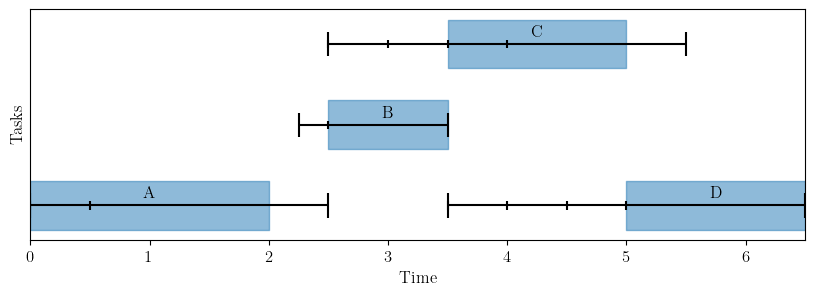

In [78]:
plt.rcParams.update({"font.size": 12})
plt.figure(figsize=(10, 3))
utils.plot_windows(
    targets, vtws, durations, task_otws, task_idxs, selected_tasks=selected_tasks
)

## SDMP - Forward Search

In [ ]:
N_targets = len(targets)
vtws = np.array(
    [
        [0, 2.5],
        [2.25, 3.5],
        [2.5, 5.5],
        [3.5, 6.5],
    ]
)
durations = np.array([2, 1, 1.5, 1.5])
rewards = np.arange(1, N_targets + 1)
power = np.array([-0.1, -0.2, -0.3, -0.4])
data = np.array([0.5, 0.6, 0.7, 0.8])
max_tasks = np.ones(N_targets, dtype=int) * 1
T = 10

In [345]:
from dataclasses import dataclass

@dataclass(frozen=True, repr=False)
class Task:
    idx: int  # Task index
    start: float  # Start time
    end: float  # End time
    reward: float  # Reward
    duration: float  # Duration
    power_gen: float  # Power generation
    data_rate: float  # Data generation
    
    def __repr__(self):
        return f"{self.idx}"

@dataclass(frozen=True, repr=False)
class State:
    time: float  # Current time
    last_task: Task  # Last task
    completed_tasks: frozenset[Task]  # Completed tasks
    data: float  # Data onboard
    energy: float  # Energy onboard

    def __repr__(self):
        return f"State(t={self.time:.2f}, d={self.data:.2f}, e={self.energy:.2f}, tasks={[task for task in self.completed_tasks]})"

@dataclass(frozen=True, repr=False)
class Action:
    task: Task

    def __repr__(self):
        return f"Action({self.task})"


tasks = list[Task]()
for i in range(N_targets):
    tasks.append(
        Task(
            idx=i,
            start=vtws[i][0],
            end=vtws[i][1],
            reward=rewards[i],
            duration=durations[i],
            power_gen=power_gen[i],
            data_rate=data_rate[i],
        )
    )

max_data = 1e3
min_data = 0
max_energy = 1e3
min_energy = 0


def available_actions(s: State) -> list[Task]:
    return [
        Action(task)
        for task in tasks
        if task.end - task.duration >= s.time and task not in s.completed_tasks
    ]


def transition_function(s: State, a: Action) -> State:
    task = a.task
    if task.start <= s.time:
        time = s.time + task.duration
    else:
        time = task.start + task.duration
    return State(
        time=time,
        last_task=task,
        completed_tasks=s.completed_tasks | {task},
        data=s.data + task.data_rate,
        energy=s.energy + task.power_gen,
    )


def reward_function(s: State, a: Action) -> float:
    return a.task.reward


def select_action(s: State, d: int, gamma: float) -> tuple[Task, float]:
    actions = available_actions(s)
    if d == 0 or not actions:
        return None, 0
    a_star, v_star = None, -np.inf
    for a in actions:
        sp = transition_function(s, a)
        ap, vp = select_action(sp, d - 1, gamma)
        v = reward_function(s, a) + gamma * vp
        if v > v_star:
            a_star, v_star = a, v
    return a_star, v_star


def smdp_forward_search(s: State, d: int, gamma: float) -> list[tuple[State, Action]]:
    policy = []
    a, v = select_action(s, d, gamma)
    while a is not None:
        policy.append((s, a))
        s = transition_function(s, a)
        a, v = select_action(s, d, gamma)
    return policy

In [346]:
initial_state = State(
    time=0, last_task=None, completed_tasks=frozenset(), data=0, energy=10
)
policy = smdp_forward_search(s=initial_state, d=4, gamma=1)
print("Tasks", [x[1].task.idx for x in policy])
print("Rewards", [x[1].task.reward for x in policy])

Tasks [0, 1, 2, 3]
Rewards [1, 2, 3, 4]


In [349]:
selected_targets = np.zeros(N_targets, dtype=bool)
task_otws = []
task_idxs = []
for s, a in policy:
    selected_targets[a.task.idx] = True
    time = max(a.task.start, s.time)
    task_otws.append([time, time + a.task.duration])
    task_idxs.append(a.task.idx)
task_otws = np.array(task_otws)
task_idxs = np.array(task_idxs)
selected_tasks = np.ones(len(task_otws), dtype=bool)

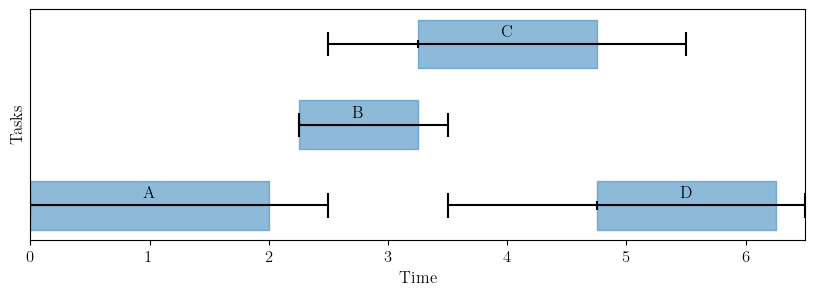

In [350]:
plt.rcParams.update({"font.size": 12})
plt.figure(figsize=(10, 3))
utils.plot_windows(
    targets, vtws, durations, task_otws, task_idxs, selected_tasks=selected_tasks
)

## SDMP - MCTS

In [398]:
from collections import defaultdict

visited = set[State]()
c = 5

N0 = defaultdict[State](lambda: defaultdict[Action](int))
Q0 = defaultdict[State](lambda: defaultdict[Action](int))

N = defaultdict[State](lambda: defaultdict[Action](int))
Q = defaultdict[State](lambda: defaultdict[Action](int))


def rollout(s: State, d: int, gamma: float) -> float:
    actions = available_actions(s)

    if d == 0 or not actions:
        return 0

    a = np.random.choice(actions)
    r = reward_function(s, a)
    sp = transition_function(s, a)
    return r + gamma * rollout(sp, d - 1, gamma)


def bonus(N_s: int, N_sa: int) -> float:
    return c * np.sqrt(np.log(N_s) / N_sa) if N_sa > 0 else np.inf


def simulate(s: State, d: int, gamma: float) -> float:
    actions = available_actions(s)

    if d == 0 or not actions:
        return 0

    if s not in visited:
        for a in actions:
            N[s, a] = N0[s, a]
            Q[s, a] = Q0[s, a]
        visited.add(s)
        return rollout(s, d, gamma)

    N_s = sum(N[s][a] for a in actions)
    a = max(actions, key=lambda a: Q[s][a] + bonus(N_s, N[s][a]))
    sp = transition_function(s, a)
    r = reward_function(s, a)
    q = r + gamma * simulate(sp, d - 1, gamma)
    N[s][a] += 1
    Q[s][a] += (q - Q[s][a]) / N[s][a]
    return q


def smdp_monte_carlo_tree_search(
    s: State, d: int, gamma: float, n: int
) -> tuple[Task, float]:
    for _ in range(n):
        simulate(s, d, gamma)

    policy = []
    actions = available_actions(s)
    while actions:
        a = max(actions, key=lambda a: Q[s][a])
        policy.append((s, a))
        s = transition_function(s, a)
        actions = available_actions(s)

    return policy


np.random.seed(0)
policy = smdp_monte_carlo_tree_search(s=initial_state, d=4, gamma=1, n=100)
print("Tasks", [x[1].task.idx for x in policy])
print("Rewards", [x[1].task.reward for x in policy])

Tasks [0, 1, 2, 3]
Rewards [1, 2, 3, 4]


In [400]:
selected_targets = np.zeros(N_targets, dtype=bool)
task_otws = []
task_idxs = []
for s, a in policy:
    selected_targets[a.task.idx] = True
    time = max(a.task.start, s.time)
    task_otws.append([time, time + a.task.duration])
    task_idxs.append(a.task.idx)
task_otws = np.array(task_otws)
task_idxs = np.array(task_idxs)
selected_tasks = np.ones(len(task_otws), dtype=bool)

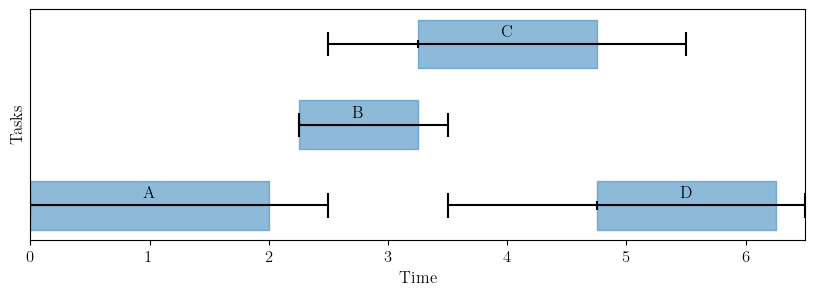

In [401]:
plt.rcParams.update({"font.size": 12})
plt.figure(figsize=(10, 3))
utils.plot_windows(
    targets, vtws, durations, task_otws, task_idxs, selected_tasks=selected_tasks
)